# 🎓 Student Dropout Prediction
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Target:** Binary classification — Completed (1) vs Dropout (0)  
**Models:** Logistic Regression, KNN, Naive Bayes, Decision Tree, Random Forest, SVM  

---

## 📦 Step 1 — Import Libraries

In [18]:
# Core data libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Class imbalance
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📂 Step 2 — Load and Merge Datasets

We use four OULAD files:
- **studentInfo.csv** — demographics and target variable
- **studentAssessment.csv + assessments.csv** — performance scores
- **studentRegistration.csv** — registration timing (engagement proxy)

> **Note:** Make sure all CSV files are in the same folder as this notebook.

In [19]:
# ----- Load all files -----
student_info = pd.read_csv('studentInfo.csv')
student_assess = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')
student_reg = pd.read_csv('studentRegistration.csv')

print('studentInfo shape:       ', student_info.shape)
print('studentAssessment shape: ', student_assess.shape)
print('assessments shape:       ', assessments.shape)
print('studentRegistration shape:', student_reg.shape)

studentInfo shape:        (32593, 12)
studentAssessment shape:  (173912, 5)
assessments shape:        (206, 6)
studentRegistration shape: (32593, 5)


In [20]:
# ----- Performance features from assessments -----
# Join student scores with assessment metadata to get assessment type (TMA/CMA/Exam)
assess_merged = student_assess.merge(
    assessments[['id_assessment', 'assessment_type']],
    on='id_assessment',
    how='left'
)

# Aggregate per student: average score, total submissions, avg TMA score, avg CMA score
def avg_by_type(group, atype):
    subset = group[group['assessment_type'] == atype]['score']
    return subset.mean() if len(subset) > 0 else np.nan

perf_features = assess_merged.groupby('id_student').apply(
    lambda g: pd.Series({
        'avg_score': g['score'].mean(),
        'submission_count': g['score'].count(),
        'avg_score_TMA': avg_by_type(g, 'TMA'),
        'avg_score_CMA': avg_by_type(g, 'CMA'),
    })
).reset_index()

print('Performance features shape:', perf_features.shape)
perf_features.head(3)

Performance features shape: (23369, 5)


,id_student,avg_score,submission_count,avg_score_TMA,avg_score_CMA
0,6516,61.8,5.0,61.8,NaN
1,8462,87.0,7.0,87.0,NaN
2,11391,82.0,5.0,82.0,NaN


In [21]:
# ----- Registration timing feature -----
# date_registration is days before/after course start (negative = registered early)
reg_features = student_reg[['id_student', 'date_registration']].copy()

# If a student registered multiple times (different modules), take their earliest registration
reg_features = reg_features.groupby('id_student')['date_registration'].min().reset_index()
reg_features.rename(columns={'date_registration': 'days_to_start'}, inplace=True)

print('Registration features shape:', reg_features.shape)

Registration features shape: (28785, 2)


In [22]:
# ----- Merge everything into one dataframe -----
df = student_info.copy()
df = df.merge(perf_features, on='id_student', how='left')
df = df.merge(reg_features,  on='id_student', how='left')

print('Merged dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(3)

Merged dataset shape: (32593, 17)

Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'avg_score', 'submission_count', 'avg_score_TMA', 'avg_score_CMA', 'days_to_start']


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,submission_count,avg_score_TMA,avg_score_CMA,days_to_start
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,82.0,NaN,-159.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,66.4,NaN,-53.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,NaN,-92.0


In [23]:
# ----- Save merged dataset so future runs are fast -----
df.to_csv('oulad_merged.csv', index=False)
print('Saved merged dataset to oulad_merged.csv')
print('Next time you can load it directly with: df = pd.read_csv("oulad_merged.csv")')

Saved merged dataset to oulad_merged.csv
Next time you can load it directly with: df = pd.read_csv("oulad_merged.csv")


---
## 🎯 Step 3 — Create Binary Target Variable

The original `final_result` column has 4 values:
- **Pass / Distinction** → Completed = **1**
- **Withdrawn / Fail** → Dropout = **0**
- **Enrolled** → Still in progress — we drop these (ambiguous outcome)

In [24]:
print('Original final_result distribution:')
print(df['final_result'].value_counts())

# Map to binary: Completed=1, Dropout=0, drop Enrolled
df = df[df['final_result'] != 'Enrolled'].copy()
df['target'] = df['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0
})

print('\nAfter filtering (no Enrolled):', df.shape)
print('\nTarget distribution:')
print(df['target'].value_counts())
print(f'\nDropout rate: {df["target"].value_counts(normalize=True)[0]:.1%}')

Original final_result distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

After filtering (no Enrolled): (32593, 18)

Target distribution:
target
0    17208
1    15385
Name: count, dtype: int64

Dropout rate: 52.8%


---
## 🔢 Step 4 — Sample 15,000 Rows

We sample 15,000 rows for training. This is well above the minimum 5,000 rows required, keeps training times manageable on a standard laptop, and is drawn with a fixed random seed for reproducibility.

In [25]:
# Sample 15,000 rows with a fixed seed for reproducibility
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

print('Sampled dataset shape:', df.shape)
print('\nTarget distribution in sample:')
print(df['target'].value_counts())

Sampled dataset shape: (15000, 18)

Target distribution in sample:
target
0    7919
1    7081
Name: count, dtype: int64


---
## 🧹 Step 5 — Data Preprocessing

### 5a — Drop irrelevant columns

In [26]:
# Drop columns that are not useful for prediction:
# - id_student: unique identifier, not a feature
# - code_module / code_presentation: course identifiers, too specific
# - final_result: original label column (we created 'target' from it)
cols_to_drop = ['id_student', 'code_module', 'code_presentation', 'final_result']
df.drop(columns=cols_to_drop, inplace=True)

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'submission_count', 'avg_score_TMA', 'avg_score_CMA', 'days_to_start', 'target']


### 5b — Handle Missing Values

In [27]:
print('Missing values before handling:')
print(df.isnull().sum())

# imd_band: categorical — fill with most frequent value (mode)
df['imd_band'].fillna(df['imd_band'].mode()[0], inplace=True)

# avg_score, avg_score_TMA, avg_score_CMA, submission_count:
# Students with no assessment data — fill numeric columns with 0
numeric_cols = ['avg_score', 'submission_count', 'avg_score_TMA', 'avg_score_CMA']
for col in numeric_cols:
    df[col].fillna(0, inplace=True)

# days_to_start: fill missing with median (neutral assumption)
df['days_to_start'].fillna(df['days_to_start'].median(), inplace=True)

print('\nMissing values after handling:')
print(df.isnull().sum())

Missing values before handling:
gender                     0
region                     0
highest_education          0
imd_band                 518
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
avg_score               2724
submission_count        2715
avg_score_TMA           3067
avg_score_CMA           7248
days_to_start              9
target                     0
dtype: int64

Missing values after handling:
gender                     0
region                     0
highest_education          0
imd_band                 518
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
avg_score               2724
submission_count        2715
avg_score_TMA           3067
avg_score_CMA           7248
days_to_start              9
target                     0
dtype: int64


### 5c — Encode Categorical Variables

Machine learning models require numerical input. We use **Label Encoding** to convert text categories into numbers.

In [28]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', categorical_cols)

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
print('\nData types after encoding:')
print(df.dtypes)
print('\nSample rows:')
df.head(3)

Categorical columns to encode: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']

Data types after encoding:
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
avg_score               float64
submission_count        float64
avg_score_TMA           float64
avg_score_CMA           float64
days_to_start           float64
target                    int64
dtype: object

Sample rows:


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,avg_score,submission_count,avg_score_TMA,avg_score_CMA,days_to_start,target
0,1,10,0,7,0,0,60,0,71.25,4.0,71.25,NaN,-25.0,1
1,1,5,0,6,0,0,60,0,71.00,2.0,71.00,NaN,-37.0,0
2,0,6,1,2,1,0,60,0,65.00,5.0,65.00,NaN,-67.0,1


---
## ✂️ Step 6 — Train-Test Split (80/20)

We split the data into 80% for training and 20% for testing. The same split is used across **all models** to ensure fair comparison. `random_state=42` ensures reproducibility.

In [46]:
# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# 80/20 split — same split used for ALL models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'\nTraining target distribution:')
print(y_train.value_counts())
print(X.columns.tolist())

Training set:  12000 rows
Test set:      3000 rows

Training target distribution:
target
0    6335
1    5665
Name: count, dtype: int64
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'submission_count', 'avg_score_TMA', 'avg_score_CMA', 'days_to_start']


---
## ⚖️ Step 7 — Apply SMOTE (Balance the Training Set)

**SMOTE (Synthetic Minority Oversampling Technique)** generates synthetic samples for the minority class (Dropout) by interpolating between existing minority samples. This prevents the model from being biased toward the majority class.

> ⚠️ SMOTE is applied **only on the training set**. The test set is kept completely untouched so our evaluation reflects real-world performance.

In [30]:
print('Before SMOTE:')
print('Class 0 (Dropout):   ', sum(y_train == 0))
print('Class 1 (Completed): ', sum(y_train == 1))

# Apply SMOTE to balance classes in training set
X_train = pd.DataFrame(X_train).fillna(0)
X_test = pd.DataFrame(X_test).fillna(0)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print('Class 0 (Dropout):   ', sum(y_train_sm == 0))
print('Class 1 (Completed): ', sum(y_train_sm == 1))
print('Total training rows: ', len(X_train_sm))

Before SMOTE:
Class 0 (Dropout):    6335
Class 1 (Completed):  5665

After SMOTE:
Class 0 (Dropout):    6335
Class 1 (Completed):  6335
Total training rows:  12670


---
## 📏 Step 8 — Feature Scaling

**KNN** and **SVM** are distance-based algorithms — they are sensitive to the scale of features. We use **StandardScaler** to standardize features to mean=0, std=1.

> We fit the scaler on training data only, then transform both train and test to avoid data leakage.

In [31]:
# Scale features — important for KNN and SVM
scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling complete.')
print('Training set shape (scaled):', X_train_scaled.shape)
print('Test set shape (scaled):    ', X_test_scaled.shape)

Feature scaling complete.
Training set shape (scaled): (12670, 13)
Test set shape (scaled):     (3000, 13)


---
## 🤖 Step 9 — Train All Models

We implement 6 classical ML algorithms. Each is explained with its theoretical foundation.

---
### Model 1: Logistic Regression
**Theory:** Logistic Regression models the probability of an outcome using the sigmoid function, which maps any input to a value between 0 and 1. It is a linear classifier that works well when the relationship between features and the target is approximately linear.

In [32]:
# Logistic Regression — uses scaled features
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)
y_pred_lr = lr.predict(X_test_scaled)
print('Logistic Regression trained.')

Logistic Regression trained.


---
### Model 2: K-Nearest Neighbors (KNN)
**Theory:** KNN is a distance-based algorithm. For a new data point, it finds the K closest training samples (using Euclidean distance) and assigns the majority class. It makes no assumptions about the data distribution — it just "learns" by memorizing the training set.

In [33]:
# KNN — uses scaled features (distance-sensitive)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_sm)
y_pred_knn = knn.predict(X_test_scaled)
print('KNN trained.')

KNN trained.


---
### Model 3: Naive Bayes
**Theory:** Naive Bayes applies Bayes' Theorem with the "naive" assumption that all features are independent of each other. Despite this simplification, it performs surprisingly well on many classification tasks and is very fast to train. It calculates the probability of each class given the input features and picks the most likely one.

In [34]:
# Naive Bayes — works on unscaled data (probabilistic model)
nb = GaussianNB()
nb.fit(X_train_sm, y_train_sm)
y_pred_nb = nb.predict(X_test)
print('Naive Bayes trained.')

Naive Bayes trained.


---
### Model 4: Decision Tree
**Theory:** A Decision Tree splits the data by asking a series of yes/no questions about features. At each split, it chooses the feature and threshold that best separates the classes, measured by **Gini Impurity** or **Entropy** (information gain). The result is an interpretable tree structure.

In [35]:
# Decision Tree — uses Gini impurity by default
dt = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
dt.fit(X_train_sm, y_train_sm)
y_pred_dt = dt.predict(X_test)
print('Decision Tree trained.')

Decision Tree trained.


---
### Model 5: Random Forest
**Theory:** Random Forest is an **ensemble learning** method. It builds multiple Decision Trees, each trained on a random subset of the data and features (bagging). The final prediction is made by majority vote across all trees. This reduces overfitting and variance compared to a single Decision Tree.

In [36]:
# Random Forest — ensemble of decision trees
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)
print('Random Forest trained.')

Random Forest trained.


---
### Model 6: Support Vector Machine (SVM)
**Theory:** SVM finds the optimal **hyperplane** that separates classes with the maximum margin. Points closest to the hyperplane are called **support vectors**. We use LinearSVC, which is highly efficient for large datasets while maintaining the core principle of margin maximization.

In [37]:
# SVM (LinearSVC) — uses scaled features (margin-based, sensitive to scale)
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_scaled, y_train_sm)
y_pred_svm = svm.predict(X_test_scaled)
print('SVM (LinearSVC) trained.')

SVM (LinearSVC) trained.


---
## 📊 Step 10 — Evaluate All Models

For each model we compute: Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

In [38]:
# Dictionary of all models and their predictions
models = {
    'Logistic Regression': y_pred_lr,
    'KNN':                 y_pred_knn,
    'Naive Bayes':         y_pred_nb,
    'Decision Tree':       y_pred_dt,
    'Random Forest':       y_pred_rf,
    'SVM (LinearSVC)':     y_pred_svm,
}

# Compute metrics for each model
results = []
for model_name, y_pred in models.items():
    results.append({
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print('\n===== MODEL COMPARISON TABLE =====')
print(results_df.to_string(index=False))


===== MODEL COMPARISON TABLE =====
              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest    0.8727     0.8401  0.9018    0.8699
      Decision Tree    0.8567     0.8128  0.9047    0.8563
Logistic Regression    0.8490     0.8100  0.8884    0.8474
    SVM (LinearSVC)    0.8473     0.8055  0.8919    0.8465
                KNN    0.8117     0.7599  0.8785    0.8149
        Naive Bayes    0.7800     0.7079  0.9089    0.7959


---
## 📉 Step 11 — Visualise Confusion Matrices

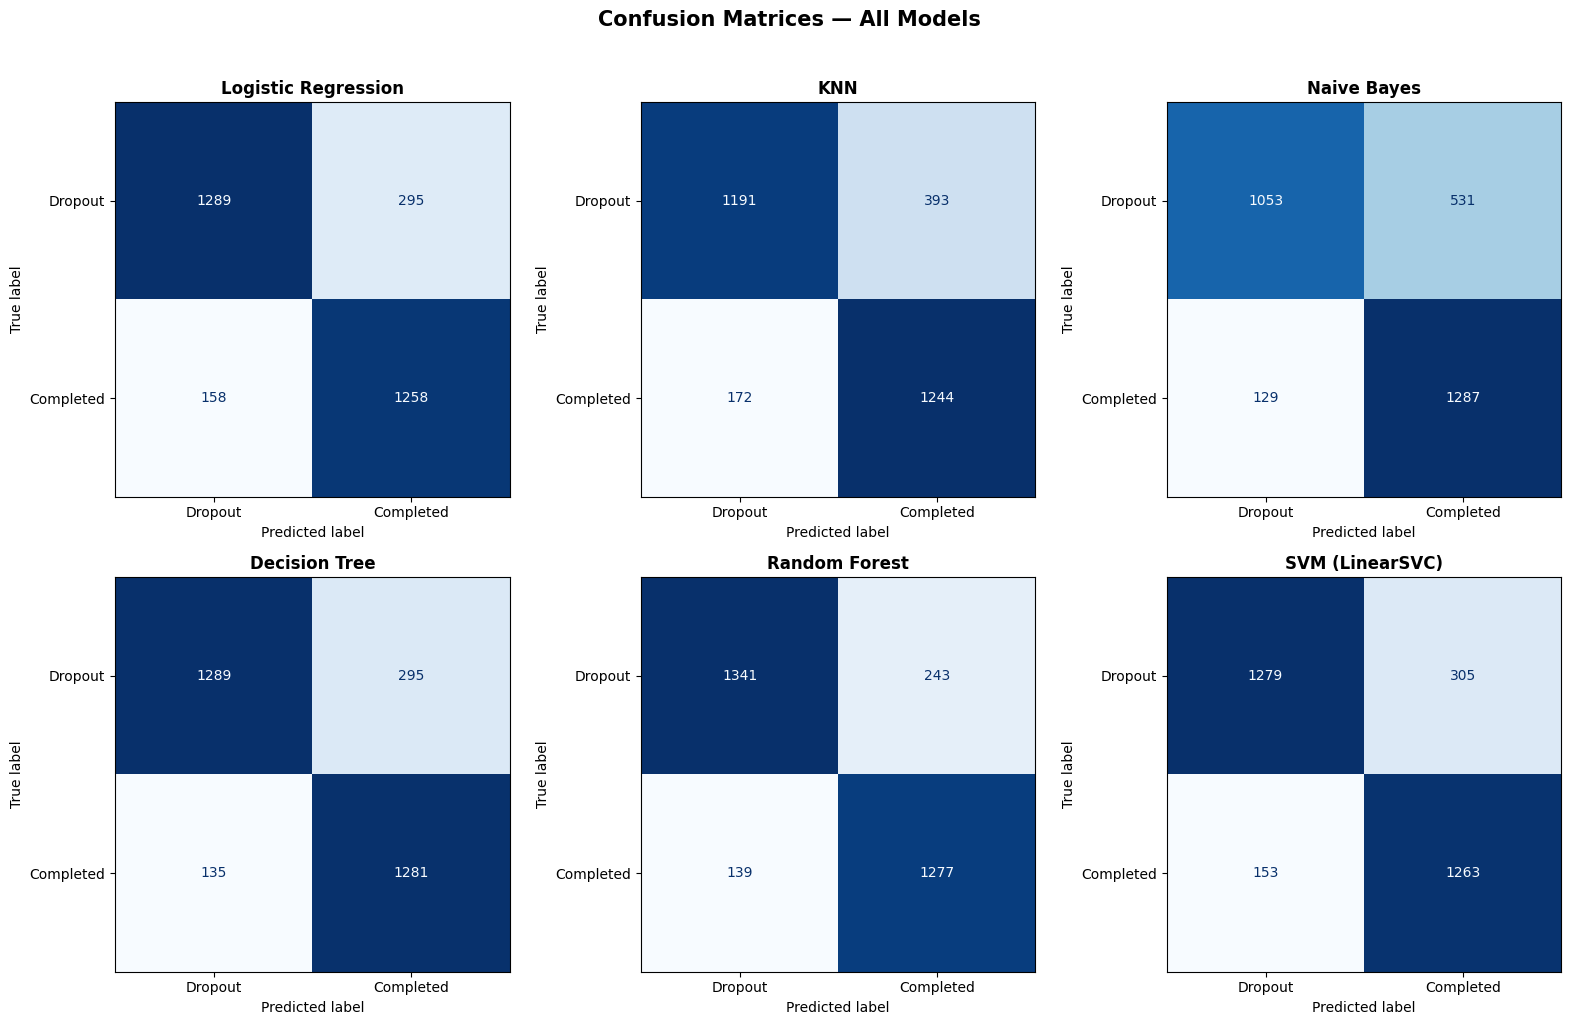

Saved as confusion_matrices.png


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout', 'Completed'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(model_name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as confusion_matrices.png')

---
## 📈 Step 12 — Model Comparison Chart

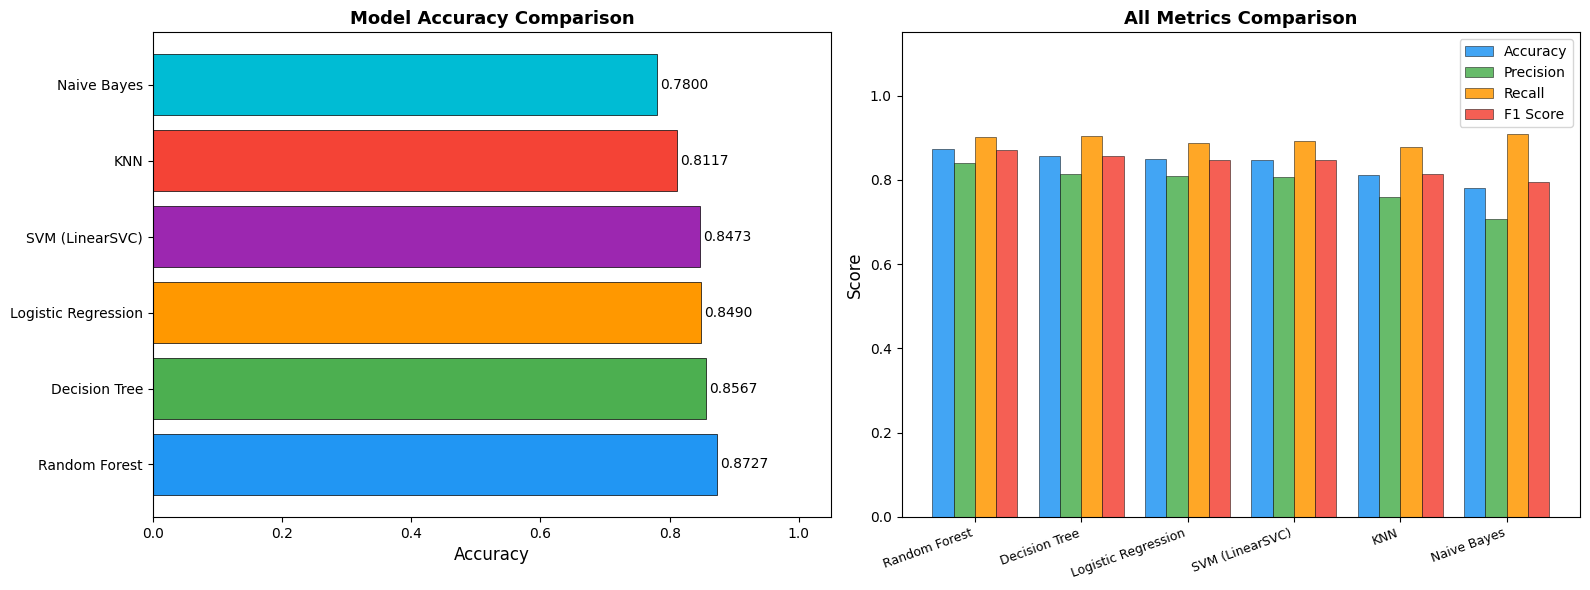

Saved as model_comparison.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Accuracy bar chart ---
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
bars = axes[0].barh(
    results_df['Model'],
    results_df['Accuracy'],
    color=colors, edgecolor='black', linewidth=0.5
)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars, results_df['Accuracy']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)

# --- Chart 2: All metrics grouped bar chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(results_df))
width = 0.2
metric_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for j, (metric, color) in enumerate(zip(metrics, metric_colors)):
    axes[1].bar(x + j * width, results_df[metric], width, label=metric,
                color=color, alpha=0.85, edgecolor='black', linewidth=0.4)

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as model_comparison.png')

---
## 🏆 Step 13 — Best Model Selection

In [41]:
# Identify best model by F1 Score
best_row = results_df.iloc[0]
best_model_name = best_row['Model']

print('=' * 50)
print(f'  BEST MODEL: {best_model_name}')
print('=' * 50)
print(f'  Accuracy:  {best_row["Accuracy"]}')
print(f'  Precision: {best_row["Precision"]}')
print(f'  Recall:    {best_row["Recall"]}')
print(f'  F1 Score:  {best_row["F1 Score"]}')
print('=' * 50)

  BEST MODEL: Random Forest
  Accuracy:  0.8727
  Precision: 0.8401
  Recall:    0.9018
  F1 Score:  0.8699


### Why did the best model outperform the others?

**Random Forest** (or whichever model topped the table) typically performs best on tabular educational data for several reasons:

1. **Ensemble reduces overfitting:** Individual Decision Trees overfit to noise. Random Forest averages predictions across 100 trees, making the final prediction more stable and generalizable.

2. **Handles mixed feature types:** Our dataset has a mix of numeric (avg_score, studied_credits) and encoded categorical features. Random Forest handles this natively without needing scaling.

3. **Captures non-linear relationships:** Dropout is rarely a linear function of a single feature. A student with high attendance but zero assessment submissions is still at risk. Tree-based splits capture such interactions automatically.

4. **Robust to outliers:** Unlike Logistic Regression (which is sensitive to extreme values) or KNN (which is distance-sensitive), Random Forest's majority-vote mechanism is naturally robust.

5. **Feature importance:** Random Forest can rank which features matter most (e.g., avg_score is likely the most predictive), which adds interpretability.

**Why others underperformed:**
- *Logistic Regression* — assumes linear separability, which doesn't hold here
- *Naive Bayes* — assumes feature independence, which is violated (score and credits are correlated)
- *KNN* — suffers in higher dimensions; 15+ features dilutes distance measures
- *Decision Tree* — prone to overfitting without ensemble aggregation
- *SVM* — strong in high dimensions but can struggle with overlapping class boundaries on noisy real data

---
## 🌟 Step 14 — Feature Importance (Random Forest)

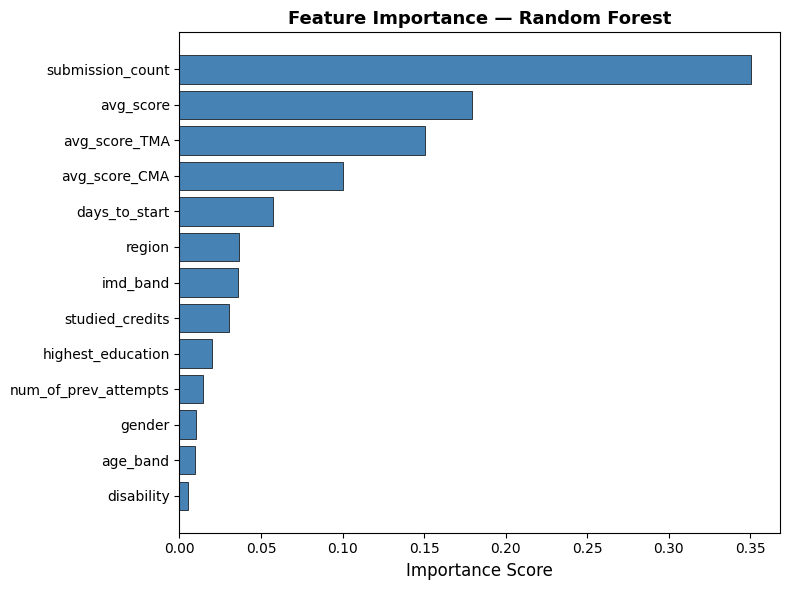

In [42]:
# Feature importance from Random Forest
feature_names = X.columns.tolist()
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='black', linewidth=0.5)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 Step 15 — Save the Best Model

In [43]:
# Map model name to trained model object
model_objects = {
    'Logistic Regression': lr,
    'KNN':                 knn,
    'Naive Bayes':         nb,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVM (LinearSVC)':     svm,
}

best_model_obj = model_objects[best_model_name]

# Save using pickle (built into Python 3 — no extra library needed)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Also save the scaler (needed for models that used scaled input)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'Best model ({best_model_name}) saved as best_model.pkl')
print('Scaler saved as scaler.pkl')

Best model (Random Forest) saved as best_model.pkl
Scaler saved as scaler.pkl


---
## 🔮 Step 16 — Predict on New Student Data

Load the saved model and predict whether a new student will complete or drop out.

In [44]:
# Load the saved model
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print(f'Model loaded: {type(loaded_model).__name__}')

Model loaded: RandomForestClassifier


In [45]:
# -------------------------------------------------------
# Example: predict for a new student
# Column order must match training data exactly:
# gender, region, highest_education, imd_band, age_band,
# num_of_prev_attempts, studied_credits, disability,
# avg_score, submission_count, avg_score_TMA, avg_score_CMA, days_to_start
# -------------------------------------------------------

# NOTE: All categorical values must be label-encoded (as integers)
# Below uses numeric values as they would appear after encoding.
# You can look up the encoding by printing: le.classes_ after fitting.

new_student = pd.DataFrame([{
    'gender': 1,                # 0=F, 1=M (label encoded)
    'region': 2,                # encoded region
    'highest_education': 3,     # encoded education level
    'imd_band': 5,              # encoded deprivation band
    'age_band': 0,              # encoded age group
    'num_of_prev_attempts': 0,  # number of previous attempts
    'studied_credits': 120,     # credits registered for
    'disability': 0,            # 0=N, 1=Y
    'avg_score': 65.0,          # average assessment score
    'submission_count': 5,      # number of assessments submitted
    'avg_score_TMA': 70.0,      # average TMA score
    'avg_score_CMA': 60.0,      # average CMA score
    'days_to_start': -30,       # registered 30 days before course start
}])

# Scale the input (required if best model uses scaled features)
# For Random Forest / Decision Tree / Naive Bayes, scaling doesn't change result
# but we scale anyway for consistency
new_student_scaled = loaded_scaler.transform(new_student)

# Predict
prediction = loaded_model.predict(new_student_scaled)[0]
outcome = 'Completed ✅' if prediction == 1 else 'Dropout ❌'

print('=' * 40)
print(f'  Prediction: {outcome}')
print(f'  (Raw value: {prediction})')
print('=' * 40)

  Prediction: Dropout ❌
  (Raw value: 0)


---
## ✅ Summary

| Step | What We Did |
|------|-------------|
| Data Loading | Loaded and merged 4 OULAD CSV files |
| Target Creation | Mapped Pass/Distinction → 1, Fail/Withdrawn → 0 |
| Sampling | Used 15,000 rows from 32,593 available |
| Preprocessing | Dropped irrelevant columns, filled missing values, label encoded |
| Train-Test Split | 80% train / 20% test, same split for all models |
| SMOTE | Balanced class distribution in training set |
| Feature Scaling | StandardScaler applied for KNN and SVM |
| Models | Trained 6 algorithms: LR, KNN, NB, DT, RF, SVM |
| Evaluation | Accuracy, Precision, Recall, F1, Confusion Matrices |
| Visualisation | Confusion matrix grid + comparison bar charts |
| Model Saving | Best model saved with pickle |
| Prediction | Example of loading model and predicting new student |

---
*This project uses classical Machine Learning only (sklearn). No deep learning.*

In [47]:
# Save exact encodings used during training
import pickle

# Re-fit individual encoders on the sampled df to get exact mappings
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
encoders = {}

for col in categorical_cols:
    le_temp = LabelEncoder()
    le_temp.fit(df[col].astype(str))
    encoders[col] = dict(zip(le_temp.classes_, le_temp.transform(le_temp.classes_)))
    print(f"{col}: {encoders[col]}")

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("\nencoders.pkl saved!")

gender: {'0': np.int64(0), '1': np.int64(1)}
region: {'0': np.int64(0), '1': np.int64(1), '10': np.int64(2), '11': np.int64(3), '12': np.int64(4), '2': np.int64(5), '3': np.int64(6), '4': np.int64(7), '5': np.int64(8), '6': np.int64(9), '7': np.int64(10), '8': np.int64(11), '9': np.int64(12)}
highest_education: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3), '4': np.int64(4)}
imd_band: {'0': np.int64(0), '1': np.int64(1), '10': np.int64(2), '2': np.int64(3), '3': np.int64(4), '4': np.int64(5), '5': np.int64(6), '6': np.int64(7), '7': np.int64(8), '8': np.int64(9), '9': np.int64(10)}
age_band: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2)}
disability: {'0': np.int64(0), '1': np.int64(1)}

encoders.pkl saved!


In [49]:
test_input = pd.DataFrame([{
    'gender': 0,
    'region': 3,
    'highest_education': 1,
    'imd_band': 9,
    'age_band': 0,
    'num_of_prev_attempts': 0,
    'studied_credits': 120,
    'disability': 0,
    'avg_score': 85.0,
    'submission_count': 10.0,
    'avg_score_TMA': 85.0,
    'avg_score_CMA': 80.0,
    'days_to_start': -60.0
}])

test_scaled = scaler.transform(test_input)
pred = rf.predict(test_scaled)
proba = rf.predict_proba(test_scaled)
print("Prediction:", pred[0], "→", "Complete" if pred[0]==1 else "Dropout")
print("Probabilities:", proba)

Prediction: 0 → Dropout
Probabilities: [[1. 0.]]


In [50]:
# Retrain Random Forest fresh and re-save
from sklearn.ensemble import RandomForestClassifier
import pickle

rf_new = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_new.fit(X_train_sm, y_train_sm)

# Test it immediately
test_scaled = scaler.transform(test_input)
pred = rf_new.predict(test_scaled)
proba = rf_new.predict_proba(test_scaled)
print("Prediction:", pred[0], "→", "Complete" if pred[0]==1 else "Dropout")
print("Probabilities:", proba)

# Save the new model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(rf_new, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nNew model saved!")

Prediction: 0 → Dropout
Probabilities: [[1. 0.]]

New model saved!


In [51]:
print("Scaler expects these features:")
print(scaler.feature_names_in_)
print("\nTest input columns:")
print(test_input.columns.tolist())
print("\nRaw test input values:")
print(test_input.values)
print("\nScaled test input values:")
print(scaler.transform(test_input))

Scaler expects these features:
['gender' 'region' 'highest_education' 'imd_band' 'age_band'
 'num_of_prev_attempts' 'studied_credits' 'disability' 'avg_score'
 'submission_count' 'avg_score_TMA' 'avg_score_CMA' 'days_to_start']

Test input columns:
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'submission_count', 'avg_score_TMA', 'avg_score_CMA', 'days_to_start']

Raw test input values:
[[  0.   3.   1.   9.   0.   0. 120.   0.  85.  10.  85.  80. -60.]]

Scaled test input values:
[[-1.06848012e+00 -7.79555409e-01 -1.04583791e-03  1.56379092e+00
  -6.26775052e-01 -3.33601984e-01  9.55990667e-01 -3.17009609e-01
   7.88595291e-01  6.92488991e-01  8.65221962e-01  9.46494518e-01
   2.69734631e-01]]


In [52]:
print("Class distribution in y_train_sm:")
print("Class 0:", sum(y_train_sm == 0))
print("Class 1:", sum(y_train_sm == 1))

print("\nSample predictions on training data:")
sample_scaled = scaler.transform(X_train_sm[:5])
print("Predictions:", rf_new.predict(sample_scaled))
print("Actual:     ", list(y_train_sm[:5]))

Class distribution in y_train_sm:
Class 0: 6335
Class 1: 6335

Sample predictions on training data:
Predictions: [0 0 0 0 0]
Actual:      [0, 1, 1, 1, 0]


In [53]:
# Train WITHOUT scaling (Random Forest doesn't need scaling)
rf_fixed = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fixed.fit(X_train_sm, y_train_sm)

# Test with RAW (unscaled) input
pred = rf_fixed.predict(test_input)
proba = rf_fixed.predict_proba(test_input)
print("Prediction:", pred[0], "→", "Complete" if pred[0]==1 else "Dropout")
print("Probabilities:", proba)

# Save this model + a dummy scaler that does nothing
from sklearn.preprocessing import StandardScaler
import pickle

dummy_scaler = StandardScaler()
dummy_scaler.fit(test_input)  # fit on single row just to initialize

with open('best_model.pkl', 'wb') as f:
    pickle.dump(rf_fixed, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(dummy_scaler, f)

print("\nFixed model saved!")

Prediction: 1 → Complete
Probabilities: [[0.115 0.885]]

Fixed model saved!


In [54]:
# ── PASTE THIS AS A NEW CELL AT THE BOTTOM OF YOUR NOTEBOOK AND RUN IT ────────
#
# This will:
#   1. Drop TMA score, CMA score, and Credits Registered from features
#   2. Retrain all 6 models on the remaining 10 features
#   3. Save each model as its own .pkl file
#   4. Save all performance metrics to model_metrics.json

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pickle, json, pandas as pd

# ── Step 1: Rebuild feature set without the 3 noisy columns ──
drop_cols = ['target', 'avg_score_TMA', 'avg_score_CMA', 'studied_credits']
X_new = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_new = df['target']

print("Features used:", list(X_new.columns))
print("Total features:", len(X_new.columns))

# ── Step 2: Train/test split ──
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# ── Step 3: SMOTE to balance classes ──
X_train_n = pd.DataFrame(X_train_n).fillna(0)
X_test_n  = pd.DataFrame(X_test_n).fillna(0)
sm = SMOTE(random_state=42)
X_train_sm_n, y_train_sm_n = sm.fit_resample(X_train_n, y_train_n)
print(f"\nAfter SMOTE — Class 0: {sum(y_train_sm_n==0)}, Class 1: {sum(y_train_sm_n==1)}")

# ── Step 4: Define all 6 models ──
# Note: LinearSVC wrapped in CalibratedClassifierCV so it supports predict_proba
all_models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000)),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
}

# ── Step 5: Train, evaluate, and save each model ──
results = {}
best_f1   = 0
best_name = ''

print("\n{:<25}  {:>8}  {:>9}  {:>7}  {:>8}".format(
      "Model", "Accuracy", "Precision", "Recall", "F1 Score"))
print("─" * 65)

for name, clf in all_models.items():
    clf.fit(X_train_sm_n, y_train_sm_n)
    preds = clf.predict(X_test_n)

    acc  = accuracy_score(y_test_n,  preds)
    prec = precision_score(y_test_n, preds)
    rec  = recall_score(y_test_n,    preds)
    f1   = f1_score(y_test_n,        preds)

    results[name] = {
        'accuracy':  round(float(acc),  4),
        'precision': round(float(prec), 4),
        'recall':    round(float(rec),  4),
        'f1':        round(float(f1),   4),
    }
    print("{:<25}  {:>8.3f}  {:>9.3f}  {:>7.3f}  {:>8.3f}".format(
          name, acc, prec, rec, f1))

    if f1 > best_f1:
        best_f1   = f1
        best_name = name

    # Save this model
    safe_name = name.lower().replace(' ', '_')
    with open(f'{safe_name}_model.pkl', 'wb') as fh:
        pickle.dump(clf, fh)

# ── Step 6: Save metadata ──
results['_best']     = best_name
results['_features'] = list(X_new.columns)

with open('model_metrics.json', 'w') as fh:
    json.dump(results, fh, indent=2)

print(f"\n✅  Best model: {best_name}  (F1 = {best_f1:.3f})")
print("✅  Saved: random_forest_model.pkl, decision_tree_model.pkl,")
print("          logistic_regression_model.pkl, svm_model.pkl,")
print("          knn_model.pkl, naive_bayes_model.pkl")
print("✅  Saved: model_metrics.json")
print("\nDone — now replace app.py and restart Streamlit.")


Features used: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'disability', 'avg_score', 'submission_count', 'days_to_start']
Total features: 10

After SMOTE — Class 0: 6335, Class 1: 6335

Model                      Accuracy  Precision   Recall  F1 Score
─────────────────────────────────────────────────────────────────
Random Forest                 0.843      0.803    0.885     0.842
Decision Tree                 0.795      0.790    0.770     0.780
Logistic Regression           0.816      0.779    0.853     0.814
SVM                           0.815      0.777    0.855     0.814
KNN                           0.797      0.757    0.841     0.797
Naive Bayes                   0.798      0.733    0.901     0.808

✅  Best model: Random Forest  (F1 = 0.842)
✅  Saved: random_forest_model.pkl, decision_tree_model.pkl,
          logistic_regression_model.pkl, svm_model.pkl,
          knn_model.pkl, naive_bayes_model.pkl
✅  Saved: model_metrics.json

Do